# End-to-End Image Captioning System

This notebook contains the complete pipeline for the Image Captioning project, broken down into logical steps.

**Pipeline:** Flickr8k dataset → text cleaning → EDA → VGG16 feature extraction → tokenizer → Merge model (CNN + LSTM) → training → BLEU evaluation (Greedy vs Beam Search) → caption your own images.

## Table of Contents
1. Import Libraries, Environment Check & Run Options
2. Dataset Download
3. Data Preprocessing
4. Exploratory Data Analysis (EDA)
5. Image Feature Extraction (VGG16)
6. Text Processing & Tokenizer
7. Model Architecture, Data Generator & Training
8. Inference & Evaluation (BLEU, Greedy vs Beam Search)
9. Single Image Captioning

> **Tip:** All slow/heavy steps are controlled by the flags in **Section 1.2 (Run Options)** — nothing expensive runs by accident when you press *Run All*.

In [1]:
import os
# Change working directory to project root if running from the notebooks folder
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
print("Current Working Directory:", os.getcwd())

Current Working Directory: f:\IDET - AI ML Diplomatic\IDET-DL-FinalProject


## 1. Import Libraries
Let's start by importing all the necessary libraries for downloading data and preprocessing text.

In [2]:
import os
import urllib.request
import zipfile
import string
import json
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
print("Imports Successfully")

Imports Successfully


### 1.1 Environment Check & Reproducibility
Before anything heavy runs, let's fix the random seeds (reproducible results) and check whether TensorFlow can see a GPU (training is **much** faster on GPU).

In [3]:
import random
import numpy as np
import tensorflow as tf

# Fix all random seeds for reproducible results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Random seeds set (SEED = {SEED})")

# Environment info
print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f"GPU detected: {gpu.name}")
else:
    print("No GPU detected - running on CPU.")
    print("(Training will be slow on CPU; inference and evaluation still work fine.)")

Random seeds set (SEED = 42)
TensorFlow version: 2.10.1
GPU detected: /physical_device:GPU:0


### 1.2 Run Options
These two flags control the slow/heavy steps of the notebook. **Nothing expensive runs by accident when you press Run All.**

In [5]:
# ======================= RUN OPTIONS =======================
DOWNLOAD_DATASET = False   # True  -> download & extract Flickr8k (~1.7GB)
TRAIN_MODEL      = False   # True  -> train the model (slow on CPU);
EVALUATE_MODEL = False                           # False -> reuse models/best_model.h5
# ===========================================================
print(f"DOWNLOAD_DATASET = {DOWNLOAD_DATASET} | TRAIN_MODEL = {TRAIN_MODEL} | EVALUATE_MODEL = {EVALUATE_MODEL}")

DOWNLOAD_DATASET = False | TRAIN_MODEL = False | EVALUATE_MODEL = False


## 2. Dataset Download
We will download the Flickr8k dataset automatically and extract it to the `data/raw` directory.

In [6]:
def download_flickr8k(download_dir="data/raw"):
    os.makedirs(download_dir, exist_ok=True)
    logging.info(f"Preparing to download Flickr8k to {download_dir}")
    
    url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"
    text_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"
    
    dataset_zip = os.path.join(download_dir, "Flickr8k.zip")
    text_zip = os.path.join(download_dir, "Flickr8k_text.zip")

    # Download Dataset
    if not os.path.exists(dataset_zip):
        logging.info("Downloading Flickr8k.zip...")
        urllib.request.urlretrieve(url, dataset_zip)
        logging.info("Download complete.")
    else:
        logging.info("Flickr8k.zip already exists.")

    # Download Text
    if not os.path.exists(text_zip):
        logging.info("Downloading Flickr8k_text.zip...")
        urllib.request.urlretrieve(text_url, text_zip)
        logging.info("Download complete.")
    else:
        logging.info("Flickr8k_text.zip already exists.")

    # Extract Dataset
    dataset_images_dir = os.path.join(download_dir, "Flicker8k")
    if not os.path.exists(dataset_images_dir):
        logging.info("Extracting Flickr8k_Dataset.zip...")
        with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
            zip_ref.extractall(download_dir)
        logging.info("Extraction complete.")
    else:
        logging.info("Flickr8k_Dataset already extracted.")

    # Extract Text
    text_dir = os.path.join(download_dir, "Flickr8k_text")
    if not os.path.exists(text_dir):
        logging.info("Extracting Flickr8k_text.zip...")
        with zipfile.ZipFile(text_zip, 'r') as zip_ref:
            zip_ref.extractall(text_dir)
        logging.info("Extraction complete.")
    else:
        logging.info("Flickr8k_text already extracted.")

Run the download function. **Note:** *The download is approximately 1.7GB, so it might take some time.*

The download is **disabled by default**. Set `DOWNLOAD_DATASET = True` in **Section 1.2 (Run Options)** to enable it — the dataset already exists in `data/raw/`, so you normally don't need to.

In [7]:
if DOWNLOAD_DATASET:
    download_flickr8k('data/raw')
else:
    print("Download skipped (DOWNLOAD_DATASET = False in Section 1.2).")
    print("Using existing dataset in data/raw/")

Download skipped (DOWNLOAD_DATASET = False in Section 1.2).
Using existing dataset in data/raw/


## 3. Data Preprocessing
Next, we need to process the raw text descriptions. We will clean the text (remove punctuation, numbers) and add `startseq` and `endseq` tokens.

In [8]:
def load_description_kaggle(filename):
    mapping = dict()
    with open(filename, 'r', encoding='utf-8') as file:
        lines = file.readlines()
    
    # skip header 'image,caption'
    for line in lines[1:]:
        line = line.strip()
        if len(line) < 2:
            continue
            
        # Split on the first comma only
        parts = line.split(',', 1)
        if len(parts) < 2:
            continue
            
        image_id, image_desc = parts[0], parts[1]
        
        # remove extension from image_id (.jpg)
        image_id = image_id.split('.')[0]
        
        if image_id not in mapping:
            mapping[image_id] = list()
        mapping[image_id].append(image_desc)
    return mapping

def clean_descriptions(descriptions):
    table = str.maketrans('', '', string.punctuation)
    for key, desc_list in descriptions.items():
        for i in range(len(desc_list)):
            desc = desc_list[i]
            desc = desc.split()
            desc = [word.lower() for word in desc]
            desc = [w.translate(table) for w in desc]
            desc = [word for word in desc if len(word) > 1]
            desc = [word for word in desc if word.isalpha()]
            desc_list[i] = 'startseq ' + ' '.join(desc) + ' endseq'

def save_descriptions(descriptions, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, 'w') as file:
        json.dump(descriptions, file, indent=4)
    logging.info(f"Saved {len(descriptions)} descriptions to {filename}")

Now we execute the preprocessing pipeline and save the clean descriptions to `data/processed/descriptions.json`.

In [9]:
raw_dir = "data/raw"
processed_dir = "data/processed"
token_file = os.path.join(raw_dir, "captions.txt")
output_file = os.path.join(processed_dir, "descriptions.json")

if not os.path.exists(token_file):
    logging.error(f"Cannot find {token_file}. Please ensure Kaggle dataset is extracted in data/raw/")
else:
    logging.info("Loading descriptions from Kaggle captions.txt...")
    descriptions = load_description_kaggle(token_file)
    logging.info(f"Loaded {len(descriptions)} image descriptions.")
    
    logging.info("Cleaning descriptions...")
    clean_descriptions(descriptions)
    
    logging.info("Saving cleaned descriptions...")
    save_descriptions(descriptions, output_file)

2026-08-29 16:34:23,010 - INFO - Loading descriptions from Kaggle captions.txt...
2026-08-29 16:34:23,150 - INFO - Loaded 8091 image descriptions.
2026-08-29 16:34:23,157 - INFO - Cleaning descriptions...
2026-08-29 16:34:23,858 - INFO - Saving cleaned descriptions...
2026-08-29 16:34:23,974 - INFO - Saved 8091 descriptions to data/processed\descriptions.json


---

## 4. Exploratory Data Analysis (EDA) & Visualization
Before moving to feature extraction, let's visualize our dataset. We will look at some images with their captions, analyze the caption lengths, and find the most common words.

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from collections import Counter
import json
import os

# Set plotting style
plt.style.use('ggplot')

### 4.1 Visualize Sample Images and Captions
Let's randomly select a few images and display them alongside their preprocessed captions.

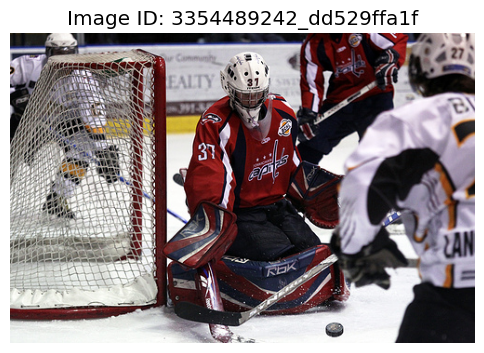

Captions:
- startseq goalie tries to block the puck in hockey game endseq
- startseq hockey goalie stops the puck endseq
- startseq people playing hockey endseq
- startseq several hockey players move toward the puck next to goal endseq
- startseq two hockey teams compete endseq




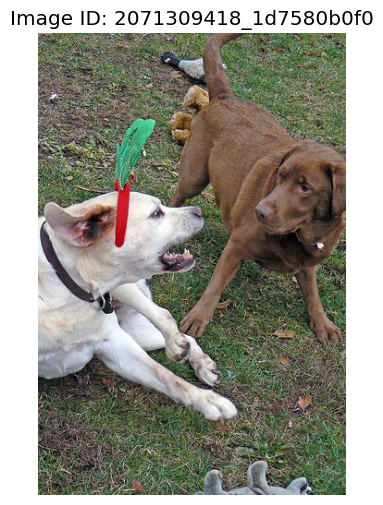

Captions:
- startseq white dog wearing christmas reindeer headband plays with brown dog in the grass among some stuffed animals endseq
- startseq white dog wearing reindeer ears is next to brown dog endseq
- startseq white dog with fake antlers on its head and brown dog play together outdoors endseq
- startseq the white dog next to the brown dog is wearing christmas headband endseq
- startseq two dogs one wearing christmas antlers tussle on the grass endseq




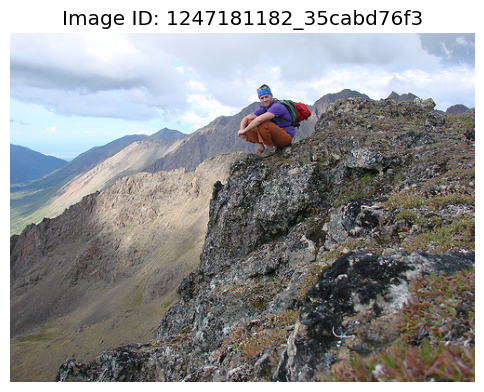

Captions:
- startseq man sits on rock endseq
- startseq man sitting on cliff in the mountains endseq
- startseq man wearing blue shirt crouches on rocky cliff endseq
- startseq person posing on mountaintop endseq
- startseq the man is sitting at the top of rocky mountain endseq




In [11]:
def visualize_samples(image_dir, descriptions_file, num_samples=3):
    if not os.path.exists(descriptions_file):
        print("Descriptions file not found. Please complete the preprocessing step first.")
        return
        
    with open(descriptions_file, 'r') as f:
        descriptions = json.load(f)
        
    image_ids = list(descriptions.keys())
    
    if not os.path.exists(image_dir):
        print(f"Image directory '{image_dir}' not found. Waiting for download to complete...")
        return
        
    sample_ids = random.sample(image_ids, num_samples)
    
    for img_id in sample_ids:
        img_path = os.path.join(image_dir, img_id + '.jpg')
        if not os.path.exists(img_path):
            continue
            
        img = mpimg.imread(img_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Image ID: {img_id}")
        plt.show()
        
        print("Captions:")
        for caption in descriptions[img_id]:
            print("-", caption)
        print("\n" + "="*50 + "\n")

# Note: Update 'data/raw/Images' to your exact extracted images folder name (e.g. 'data/raw/Flicker8k_Dataset')
visualize_samples('data/raw/Images', 'data/processed/descriptions.json')

### 4.2 Analyze Caption Lengths
Let's plot a histogram of how many words are in each caption. This will help us decide the `max_length` parameter for our LSTM model later.

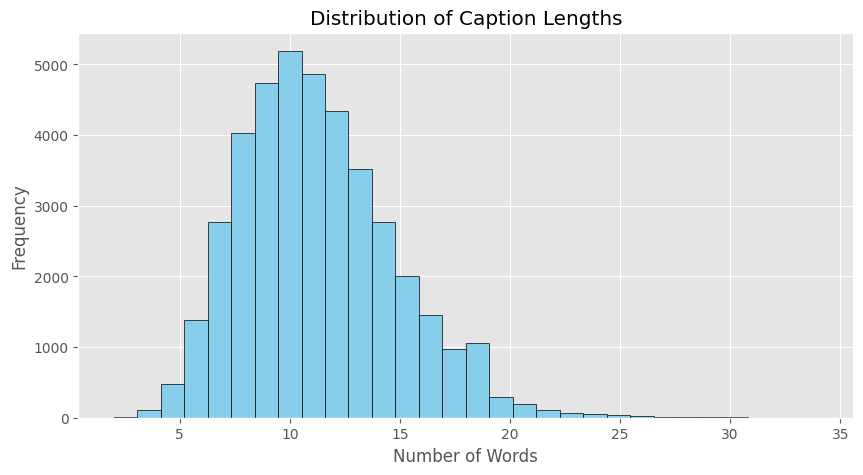

Maximum caption length: 34 words
Average caption length: 11.22 words


In [12]:
def analyze_caption_lengths(descriptions_file):
    if not os.path.exists(descriptions_file):
        return
        
    with open(descriptions_file, 'r') as f:
        descriptions = json.load(f)
        
    all_lengths = []
    for captions in descriptions.values():
        for cap in captions:
            # Split by space to get words
            words = cap.split()
            all_lengths.append(len(words))
            
    plt.figure(figsize=(10, 5))
    plt.hist(all_lengths, bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribution of Caption Lengths')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.show()
    
    print(f"Maximum caption length: {max(all_lengths)} words")
    print(f"Average caption length: {sum(all_lengths)/len(all_lengths):.2f} words")

analyze_caption_lengths('data/processed/descriptions.json')

### 4.3 Top 20 Most Frequent Words
Let's see which words appear the most in our dataset (excluding the `startseq` and `endseq` tags).

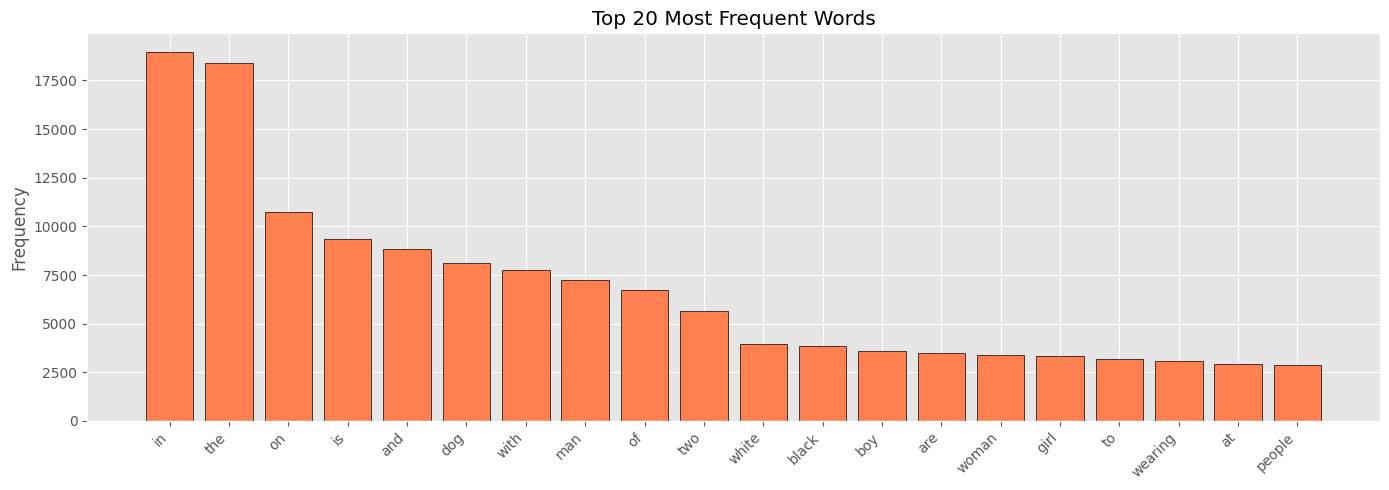

Total unique words (Vocabulary Size): 8763


In [13]:
def plot_top_words(descriptions_file, top_n=50):
    if not os.path.exists(descriptions_file):
        return

    with open(descriptions_file, 'r') as f:
        descriptions = json.load(f)

    all_words = []
    for captions in descriptions.values():
        for cap in captions:
            words = cap.split()
            # Remove startseq and endseq for word frequency analysis
            words = [w for w in words if w not in ['startseq', 'endseq']]
            all_words.extend(words)

    word_counts = Counter(all_words)
    common_words = word_counts.most_common(top_n)

    words, counts = zip(*common_words)

    plt.figure(figsize=(14, 5))
    plt.bar(words, counts, color='coral', edgecolor='black')
    plt.title(f'Top {top_n} Most Frequent Words')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

    print(f"Total unique words (Vocabulary Size): {len(word_counts)}")

plot_top_words('data/processed/descriptions.json', top_n=20)

### 4.4 Word Cloud of Captions
A Word Cloud is a great way to visually see the most prominent words in our dataset.

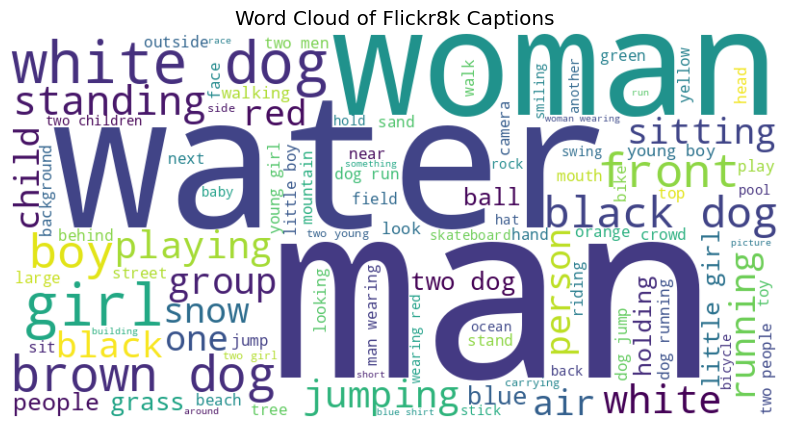

In [14]:
def generate_word_cloud(descriptions_file):
    try:
        from wordcloud import WordCloud
    except ImportError:
        print("wordcloud is not installed. Install it with:  pip install wordcloud")
        return

    if not os.path.exists(descriptions_file):
        return

    with open(descriptions_file, 'r') as f:
        descriptions = json.load(f)

    all_text = ""
    for captions in descriptions.values():
        for cap in captions:
            # Remove startseq and endseq
            clean_cap = cap.replace('startseq ', '').replace(' endseq', '')
            all_text += " " + clean_cap

    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis', max_words=100).generate(all_text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud of Flickr8k Captions')
    plt.show()

generate_word_cloud('data/processed/descriptions.json')

### 4.5 Word Frequency Distribution (Rare vs Common Words)
Let's see how many words appear only once or twice compared to those that appear many times. This helps us decide if we need to filter out rare words to reduce vocabulary size.

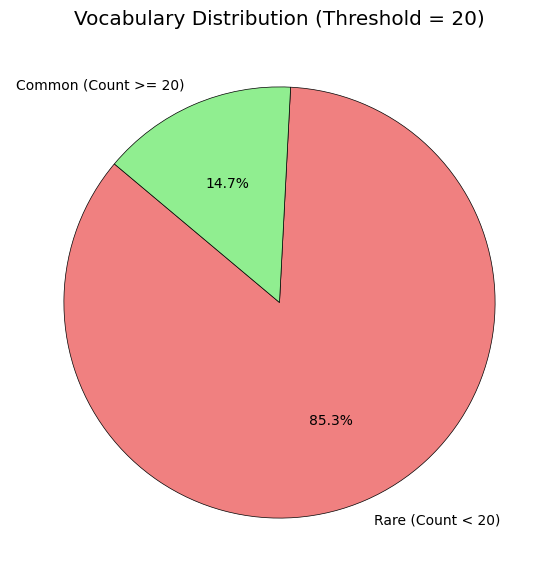

Total vocabulary size: 8763
Words appearing less than 20 times: 7474
Words appearing 20 or more times: 1289
Filtering out rare words can significantly reduce model complexity!


In [15]:
def analyze_word_frequencies(descriptions_file):
    if not os.path.exists(descriptions_file):
        return
        
    with open(descriptions_file, 'r') as f:
        descriptions = json.load(f)
        
    all_words = []
    for captions in descriptions.values():
        for cap in captions:
            words = cap.split()
            words = [w for w in words if w not in ['startseq', 'endseq']]
            all_words.extend(words)
            
    word_counts = Counter(all_words)
    
    threshold = 20
    rare_words = [w for w, c in word_counts.items() if c < threshold]
    common_words = [w for w, c in word_counts.items() if c >= threshold]
    
    labels = [f'Rare (Count < {threshold})', f'Common (Count >= {threshold})']
    sizes = [len(rare_words), len(common_words)]
    colors = ['lightcoral', 'lightgreen']
    
    plt.figure(figsize=(7, 7))
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
    plt.title(f'Vocabulary Distribution (Threshold = {threshold})')
    plt.show()
    
    print(f"Total vocabulary size: {len(word_counts)}")
    print(f"Words appearing less than {threshold} times: {len(rare_words)}")
    print(f"Words appearing {threshold} or more times: {len(common_words)}")
    print("Filtering out rare words can significantly reduce model complexity!")

analyze_word_frequencies('data/processed/descriptions.json')

### 4.6 Verify Captions Per Image
Finally, let's verify that the dataset is balanced and each image has exactly 5 captions.

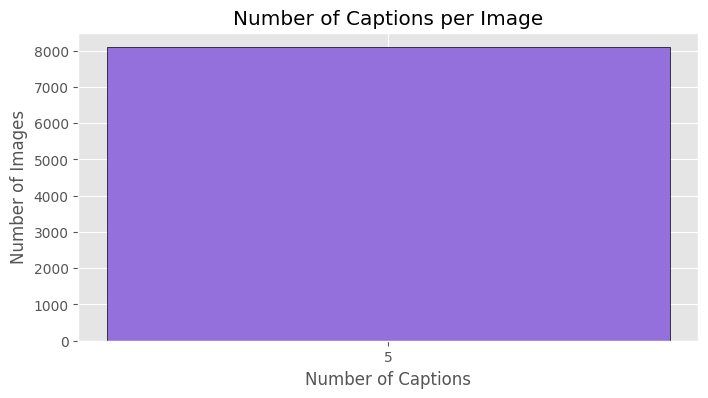

8091 images have 5 captions.


In [16]:
def check_captions_per_image(descriptions_file):
    if not os.path.exists(descriptions_file):
        return
        
    with open(descriptions_file, 'r') as f:
        descriptions = json.load(f)
        
    counts = [len(caps) for caps in descriptions.values()]
    count_distribution = Counter(counts)
    
    plt.figure(figsize=(8, 4))
    plt.bar(count_distribution.keys(), count_distribution.values(), color='mediumpurple', edgecolor='black')
    plt.title('Number of Captions per Image')
    plt.xlabel('Number of Captions')
    plt.ylabel('Number of Images')
    plt.xticks(list(count_distribution.keys()))
    plt.show()
    
    for k, v in count_distribution.items():
        print(f"{v} images have {k} captions.")

check_captions_per_image('data/processed/descriptions.json')

### 4.7 Train / Test Data Split
We are using the **official Flickr8k splits** provided by the original authors (6000 train, 1000 dev, 1000 test). These text files contain the image names.

In [17]:
import os
train_file = 'data/raw/Flickr_8k.trainImages.txt'
dev_file = 'data/raw/Flickr_8k.devImages.txt'
test_file = 'data/raw/Flickr_8k.testImages.txt'

for f in [train_file, dev_file, test_file]:
    if os.path.exists(f):
        with open(f, 'r') as file:
            lines = file.readlines()
        print(f"{os.path.basename(f)}: {len(lines)} images")
    else:
        print(f"Error: {f} not found!")

Flickr_8k.trainImages.txt: 6000 images
Flickr_8k.devImages.txt: 1000 images
Flickr_8k.testImages.txt: 1000 images


---
## 5. Image Feature Extraction (Task 3)
In this step, we use a pre-trained **VGG16** Convolutional Neural Network (CNN) to extract features from our images. 
Instead of using VGG16 to classify images, we will remove its final classification layer and take the output from the second-to-last layer (`fc2`). This will give us a dense **4096-dimensional vector** for each image, which represents the visual features of that image.

We will extract features for all 8,000 images and save them in a `.pkl` (pickle) file so we don't have to re-calculate them every time.

In [18]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import pickle
import os
from tqdm.notebook import tqdm

def extract_image_features(image_directory, output_file='data/processed/features.pkl'):
    # Load VGG16 model pre-trained on ImageNet
    # We load the full model first
    model = VGG16()
    
    # Re-structure the model: we want the output of the 'fc2' layer (index -2)
    model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
    
    print("VGG16 Feature Extractor Model loaded successfully.")
    
    features = dict()
    
    if not os.path.exists(image_directory):
        print(f"Directory {image_directory} not found!")
        return
        
    image_list = [f for f in os.listdir(image_directory) if f.endswith('.jpg')]
    print(f"Extracting features for {len(image_list)} images. This may take some time...")
    
    for image_name in tqdm(image_list, desc="Extracting Features"):
        image_path = os.path.join(image_directory, image_name)
        
        # Load and resize image to VGG16 expected size (224x224)
        image = load_img(image_path, target_size=(224, 224))
        
        # Convert image to numpy array
        image = img_to_array(image)
        
        # Reshape data for the model: (1, 224, 224, 3)
        image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
        
        # Preprocess the image (normalize channels as VGG16 expects)
        image = preprocess_input(image)
        
        # Get features
        feature = model.predict(image, verbose=0)
        
        # Store in dictionary using image ID (without .jpg)
        image_id = image_name.split('.')[0]
        features[image_id] = feature
        
    # Save the features to a pickle file
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, 'wb') as f:
        pickle.dump(features, f)
        
    print(f"Successfully extracted and saved {len(features)} image features to {output_file}")
    return features




In [19]:
if os.path.exists("data/processed/features.pkl"):
    with open('data/processed/features.pkl', 'rb') as f:
        features = pickle.load(f)
    print(f"Loaded {len(features)} pre-extracted features.")
else:
    image_dir = 'data/raw/Images'
    features = extract_image_features(image_dir)

print("Features loaded")



Loaded 8091 pre-extracted features.
Features loaded


---
## 6. Text Processing & Tokenizer Engine (Task 4)
Neural networks cannot process raw text. We need to convert our words into numbers. 
To do this, we will:
1. Load only the **training image descriptions** (to prevent data leakage).
2. Use the Keras `Tokenizer` to map every unique word to an integer.
3. Calculate the **Vocabulary Size** and the **Maximum Sequence Length** (the length of the longest caption).
4. Save the tokenizer so we can use it during inference (when generating captions for new images).

In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
import json
import os
import pickle

def load_doc(filename):
    with open(filename, 'r') as file:
        return file.read()

def create_tokenizer(descriptions_file, train_images_file, output_file='models/tokenizer.pkl'):
    # Load all cleaned descriptions
    with open(descriptions_file, 'r') as f:
        all_descriptions = json.load(f)
        
    # Load training image IDs and remove .jpg extension
    train_image_ids = load_doc(train_images_file).split('\n')
    train_image_ids = [img_id.split('.')[0].strip() for img_id in train_image_ids if img_id.strip()]
    
    # Filter descriptions to only include training images
    train_captions = []
    for image_id in train_image_ids:
        if image_id in all_descriptions:
            train_captions.extend(all_descriptions[image_id])
            
    print(f"Loaded {len(train_captions)} training captions.")
    
    # Initialize the Keras Tokenizer
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(train_captions)
    
    # Vocabulary size (add 1 for the 0 padding token)
    vocab_size = len(tokenizer.word_index) + 1
    
    # Calculate the maximum length of a caption
    max_length = max(len(caption.split()) for caption in train_captions)
    
    print(f"Vocabulary Size: {vocab_size}")
    print(f"Maximum Sequence Length: {max_length}")
    
    # Save the tokenizer
    os.makedirs(os.path.dirname(output_file), exist_ok=True)
    with open(output_file, 'wb') as f:
        pickle.dump(tokenizer, f)
        
    print(f"Tokenizer saved to {output_file}")
    
    return tokenizer, vocab_size, max_length



In [21]:
tokenizer, vocab_size, max_length = create_tokenizer('data/processed/descriptions.json', 'data/raw/Flickr_8k.trainImages.txt')


Loaded 30000 training captions.
Vocabulary Size: 7579
Maximum Sequence Length: 34
Tokenizer saved to models/tokenizer.pkl


In [22]:
print(f"vocab Size: {vocab_size}")
print(f"Max Length: {max_length}")

vocab Size: 7579
Max Length: 34


---
## 7. Deep Learning Architecture (Task 5)
Now we define the actual **Merge Model**. The model consists of three parts:
1. **Image Feature Extractor**: Processes the 4096-d features from VGG16 through a Dense layer.
2. **Sequence Processor**: Processes text sequences through an Embedding layer and an LSTM layer.
3. **Decoder / Fusion Layer**: Combines the output of the two parts and predicts the next word using a Softmax layer.

In [23]:
import yaml
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.utils import plot_model

# Load config
with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

embedding_dim = config['model']['embedding_dim']

def define_model(vocab_size, max_length, embedding_dim):
    # 1. Image Feature Extractor
    inputs1 = Input(shape=(4096,), name="image_features")
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(embedding_dim, activation='relu')(fe1)

    # 2. Sequence Processor
    inputs2 = Input(shape=(max_length,), name="text_sequences")
    # mask_zero=True tells the model to ignore padding zeroes
    se1 = Embedding(vocab_size, embedding_dim, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(embedding_dim)(se2)

    # 3. Decoder / Fusion Layer
    decoder1 = add([fe2, se3])
    decoder2 = Dense(embedding_dim, activation='relu')(decoder1)
    outputs = Dense(vocab_size, activation='softmax', name="predicted_word")(decoder2)

    # Tie it all together
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)

    # Compile the model
    model.compile(loss='categorical_crossentropy', optimizer='adam')

    # Summarize model
    print(model.summary())
    return model

model = define_model(vocab_size, max_length, embedding_dim)

# Optional: export an architecture diagram (requires pydot + graphviz; safe to skip)
try:
    plot_model(model, to_file='models/model_architecture.png', show_shapes=True, show_layer_names=True)
    print("Architecture diagram saved -> models/model_architecture.png")
except Exception as e:
    print(f"plot_model skipped ({type(e).__name__}). Install graphviz + pydot to render the diagram.")

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_sequences (InputLayer)    [(None, 34)]         0           []                               
                                                                                                  
 image_features (InputLayer)    [(None, 4096)]       0           []                               
                                                                                                  
 embedding (Embedding)          (None, 34, 256)      1940224     ['text_sequences[0][0]']         
                                                                                                  
 dropout (Dropout)              (None, 4096)         0           ['image_features[0][0]']         
                                                                                              

### 7.1 Progressive Data Generator
Since image and text combinations generate millions of rows of data, it will crash your RAM if loaded all at once. We use a **Custom Data Generator** (`tf.keras.utils.Sequence`) to generate data in small batches progressively during training.

In [24]:
import numpy as np
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import json
import pickle

class DataGenerator(Sequence):
    def __init__(self, descriptions, features, tokenizer, max_length, vocab_size, image_ids, batch_size, shuffle=True):
        self.descriptions = descriptions
        self.features = features
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.vocab_size = vocab_size
        self.image_ids = list(image_ids)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.image_ids))
        self.on_epoch_end()

    def __len__(self):
        # Calculate number of batches per epoch
        return int(np.ceil(len(self.image_ids) / float(self.batch_size)))

    def on_epoch_end(self):
        # Shuffle the sample order after every epoch so the model does not
        # see the batches in the exact same order every time (reduces overfitting).
        self.indices = np.arange(len(self.image_ids))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        # Get batch of image IDs (via the shuffled index map)
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_ids = [self.image_ids[i] for i in batch_indices]
        X1, X2, y = list(), list(), list()

        for image_id in batch_ids:
            if image_id not in self.features or image_id not in self.descriptions:
                continue

            # The features loaded from pickle are shape (1, 4096), we take the first element
            feature = self.features[image_id][0]

            for desc in self.descriptions[image_id]:
                # encode sequence
                seq = self.tokenizer.texts_to_sequences([desc])[0]

                # split one sequence into multiple X, y pairs
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]
                    # pad input sequence
                    in_seq = pad_sequences([in_seq], maxlen=self.max_length)[0]
                    # encode output sequence (one-hot encoding)
                    out_seq = to_categorical([out_seq], num_classes=self.vocab_size)[0]

                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_seq)

        return [np.array(X1), np.array(X2)], np.array(y)

In [25]:
# Load descriptions and features for the generator
with open('data/processed/descriptions.json', 'r') as f:
    all_descriptions = json.load(f)

print("Loading image features (this might take a few seconds)...")
with open('data/processed/features.pkl', 'rb') as f:
    all_features = pickle.load(f)



Loading image features (this might take a few seconds)...


In [26]:
def load_ids(filepath):
    with open(filepath, 'r') as f:
        ids = f.read().split('\n')
    return [i.split('.')[0] for i in ids if i.strip()]


In [27]:
train_ids = load_ids('data/raw/Flickr_8k.trainImages.txt')
val_ids = load_ids('data/raw/Flickr_8k.devImages.txt')

print(f"Train IDs: {len(train_ids)}, Validation IDs: {len(val_ids)}")


Train IDs: 6000, Validation IDs: 1000


### 7.2 Training the Model
Now we will define training callbacks (like `ModelCheckpoint` to save the best model and `EarlyStopping` to stop if it stops improving) and train the neural network.

In [28]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard, CSVLogger
import os

# Create model directory
os.makedirs('models', exist_ok=True)

# Create TensorBoard log directory (Task 5.3)
log_dir = os.path.join('logs', 'image_captioning')
os.makedirs(log_dir, exist_ok=True)

# Load training parameters from config
batch_size = config['training']['batch_size']
epochs = config['training']['epochs']

print(f"Loaded config: Batch Size = {batch_size}, Epochs = {epochs}")
print(f"TensorBoard logs -> {log_dir} (run: tensorboard --logdir {log_dir})")

# Define generators
train_generator = DataGenerator(all_descriptions, all_features, tokenizer, max_length, vocab_size, train_ids, batch_size)
val_generator = DataGenerator(all_descriptions, all_features, tokenizer, max_length, vocab_size, val_ids, batch_size, shuffle=False)

# Define callbacks
checkpoint = ModelCheckpoint('models/best_model.h5', monitor='val_loss', save_best_only=True, mode='min', verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
tensorboard_cb = TensorBoard(log_dir=log_dir, histogram_freq=1)
# Persist per-epoch metrics so the loss curve can be plotted even without a live `history` object
csv_logger = CSVLogger('models/training_history.csv', append=True)

Loaded config: Batch Size = 32, Epochs = 20
TensorBoard logs -> logs\image_captioning (run: tensorboard --logdir logs\image_captioning)


In [29]:
if TRAIN_MODEL:
    print("Training started - this can take a long time (best done on GPU or overnight).")
    history = model.fit(
        train_generator,
        epochs=epochs,
        validation_data=val_generator,
        callbacks=[checkpoint, early_stopping, reduce_lr, tensorboard_cb, csv_logger]
    )
    print("Training complete.")
    print("- Best model  -> models/best_model.h5")
    print("- History     -> models/training_history.csv")
    print(f"- TensorBoard -> {log_dir}")
else:
    history = None
    print("Training is DISABLED (set TRAIN_MODEL = True in Section 1.2 to enable).")
    print("The evaluation below will use the pre-trained checkpoint: models/best_model.h5")

Training is DISABLED (set TRAIN_MODEL = True in Section 1.2 to enable).
The evaluation below will use the pre-trained checkpoint: models/best_model.h5


---
## 8. Inference & Evaluation (Task 6)
Once the model is trained, we evaluate it on the **Test Dataset** (1,000 images it has never seen before).

- The evaluation automatically loads the **best saved checkpoint** (`models/best_model.h5`) instead of the in-memory weights (which may be untrained if training was skipped).
- **Greedy Search**: generate the caption word by word, always picking the most probable word.
- **Beam Search**: keep the top-k candidate sequences at each step (usually slightly better BLEU scores).
- **BLEU Score**: the standard NLTK `corpus_bleu` metric, comparing the generated caption with the 5 human reference captions.

> **Runtime note:** evaluating all 1,000 test images takes a few minutes on CPU. Reduce `test_ids` (e.g. `test_ids[:100]`) for a quick sanity check.

In [30]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import corpus_bleu
from tqdm.notebook import tqdm

# O(1) id -> word lookup table.
# (Scanning tokenizer.word_index for every predicted word is O(vocab_size) per word
#  and makes evaluation / beam search needlessly slow.)
index_word = {v: k for k, v in tokenizer.word_index.items()}

def generate_desc(model, tokenizer, photo, max_length):
    """Greedy decoding: pick the single most probable word at each step."""
    # Seed the generation process
    in_text = 'startseq'
    # Iterate over the whole length of maximum sequence
    for _ in range(max_length):
        # Integer encode input sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # Pad input
        sequence = pad_sequences([sequence], maxlen=max_length)
        # Predict next word
        yhat = model.predict([photo, sequence], verbose=0)
        # Convert probability to integer, then to word (O(1) lookup)
        word = index_word.get(int(np.argmax(yhat)))
        # Stop if we cannot map the word
        if word is None:
            break
        # Append as input for generating the next word
        in_text += ' ' + word
        # Stop if we predict the end of the sequence
        if word == 'endseq':
            break
    return in_text

def generate_desc_beam_search(model, tokenizer, photo, max_length, beam_index=3):
    """Beam Search decoding (Task 6.2): keep the top-k candidate sequences."""
    start_seq = [tokenizer.word_index['startseq']]
    # List of [sequence, cumulative_log_probability] candidates
    candidates = [[start_seq, 0.0]]

    while len(candidates[0][0]) < max_length:
        expanded = []
        for seq, score in candidates:
            # Do not expand sequences that already ended
            if index_word.get(seq[-1]) == 'endseq':
                expanded.append([seq, score])
                continue
            sequence = pad_sequences([seq], maxlen=max_length)
            yhat = model.predict([photo, sequence], verbose=0)[0]
            # Expand along the top beam_index words
            for word_id in np.argsort(yhat)[-beam_index:]:
                new_seq = seq + [int(word_id)]
                # Accumulate log-probability (numerically stable)
                new_score = score + np.log(yhat[word_id] + 1e-10)
                expanded.append([new_seq, new_score])
        # Keep only the top beam_index candidates
        candidates = sorted(expanded, key=lambda x: x[1])[-beam_index:]
        # Stop when the best candidate ended with 'endseq'
        if index_word.get(candidates[-1][0][-1]) == 'endseq':
            break

    best_seq = candidates[-1][0]
    words = [index_word.get(i) for i in best_seq]
    return ' '.join([w for w in words if w is not None])

def evaluate_model(model, descriptions, features, tokenizer, max_length, test_ids, beam_search=False, beam_index=3):
    """Generate captions for the test set and return the BLEU-1..4 scores."""
    strategy = f"Beam Search (k={beam_index})" if beam_search else "Greedy"
    actual, predicted = list(), list()
    # Step over the whole set
    for key in tqdm(test_ids, desc=f"Evaluating ({strategy})"):
        if key not in features or key not in descriptions:
            continue
        # Get actual image feature (shape: 1, 4096)
        feature = features[key]

        # Generate description with the selected decoding strategy
        if beam_search:
            yhat = generate_desc_beam_search(model, tokenizer, feature, max_length, beam_index)
        else:
            yhat = generate_desc(model, tokenizer, feature, max_length)

        # yhat looks like: "startseq a dog runs endseq" -> remove startseq and endseq for fair comparison
        yhat_clean = yhat.replace('startseq ', '').replace(' endseq', '')

        references = [d.replace('startseq ', '').replace(' endseq', '').split() for d in descriptions[key]]
        actual.append(references)
        predicted.append(yhat_clean.split())

    # Calculate BLEU scores
    scores = {
        'BLEU-1': corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)),
        'BLEU-2': corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)),
        'BLEU-3': corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0)),
        'BLEU-4': corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25)),
    }
    print(f"--- {strategy} ---")
    for name, value in scores.items():
        print(f"{name}: {value:.6f}")
    return scores

In [31]:
test_ids = load_ids('data/raw/Flickr_8k.testImages.txt')
print(f"Loaded {len(test_ids)} test images.")

Loaded 1000 test images.


In [37]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

if EVALUATE_MODEL:   
    

    # Evaluate with the BEST saved checkpoint - NOT the in-memory weights,
    # which are untrained if you skipped the training step.
    if os.path.exists('models/best_model.h5'):
        print("Loading checkpoint: models/best_model.h5")
        eval_model = load_model('models/best_model.h5')
    else:
        print("WARNING: models/best_model.h5 not found - falling back to the in-memory model.")
        print("(Train the model first, or run train_model.py, for meaningful scores.)")
        eval_model = model

    # Task 6.2: Compare Greedy Search vs Beam Search decoding strategies
    print("Evaluating model with Greedy Search...")
    greedy_scores = evaluate_model(eval_model, all_descriptions, all_features, tokenizer, max_length, test_ids, beam_search=False)

    print("\n    Evaluating model with Beam Search...")
    beam_scores = evaluate_model(eval_model, all_descriptions, all_features, tokenizer, max_length, test_ids, beam_search=True, beam_index=3)

    # Visual comparison of the two decoding strategies
    labels = list(greedy_scores.keys())
    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width/2, [greedy_scores[k] for k in labels], width, label='Greedy', color='steelblue', edgecolor='black')
    plt.bar(x + width/2, [beam_scores[k] for k in labels], width, label='Beam Search (k=3)', color='darkorange', edgecolor='black')
    for i, k in enumerate(labels):
        plt.text(i - width/2, greedy_scores[k] + 0.005, f"{greedy_scores[k]:.3f}", ha='center', fontsize=9)
        plt.text(i + width/2, beam_scores[k] + 0.005, f"{beam_scores[k]:.3f}", ha='center', fontsize=9)
    plt.xticks(x, labels)
    plt.ylabel('Score')
    plt.title('Greedy vs Beam Search - BLEU Scores on Test Set')
    plt.legend()
    plt.ylim(0, max(max(greedy_scores.values()), max(beam_scores.values())) * 1.2)
    plt.show()
else:
    eval_model = load_model('models/best_model.h5')
    print('Evaluation is DISABLED (set EVALUATE_MODEL = True in Section 1.2 to enable).')

Evaluation is DISABLED (set EVALUATE_MODEL = True in Section 1.2 to enable).


### 8.1 Plot Training History
Visualizing the loss curve helps us understand if the model is learning properly, overfitting, or underfitting.

(Loaded history from models/training_history.csv - 3 epochs)


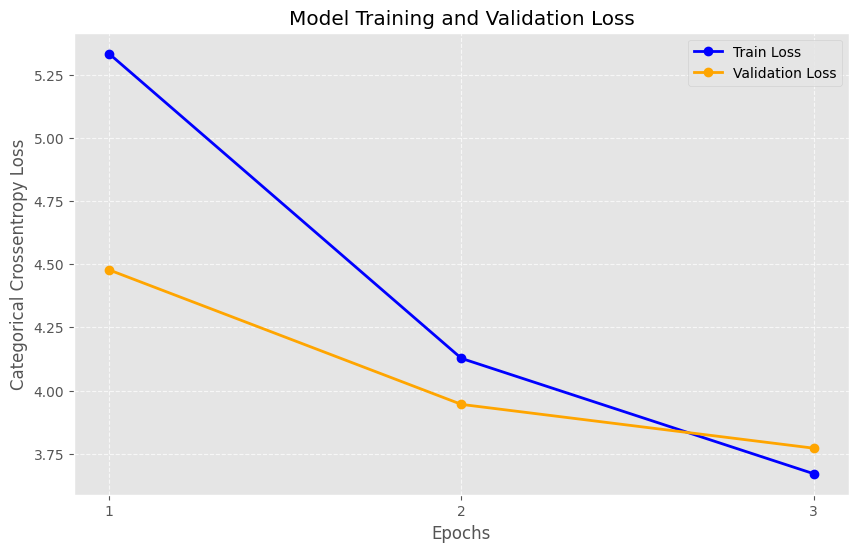

In [38]:
import matplotlib.pyplot as plt
import csv

def plot_training_history(history=None, csv_path='models/training_history.csv'):
    """Plot train/validation loss from a live `history` object, or fall back to
    the CSV written by CSVLogger during a previous training run."""
    if history is not None:
        train_loss = history.history['loss']
        val_loss = history.history['val_loss']
    elif os.path.exists(csv_path):
        train_loss, val_loss = [], []
        with open(csv_path, 'r') as f:
            for row in csv.DictReader(f):
                train_loss.append(float(row['loss']))
                val_loss.append(float(row['val_loss']))
        if not train_loss:
            print("History CSV is empty. Train the model first.")
            return
        print(f"(Loaded history from {csv_path} - {len(train_loss)} epochs)")
    else:
        print("No training history found. Train first (TRAIN_MODEL = True) or run train_model.py.")
        return

    epochs_range = list(range(1, len(train_loss) + 1))
    plt.figure(figsize=(10, 6))
    plt.plot(epochs_range, train_loss, label='Train Loss', color='blue', linewidth=2, marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2, marker='o')
    plt.title('Model Training and Validation Loss')
    plt.ylabel('Categorical Crossentropy Loss')
    plt.xlabel('Epochs')
    plt.xticks(epochs_range)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_training_history(history)

### 8.2 Visualize Test Predictions
BLEU scores are just numbers. It's much better to actually *see* what the model is predicting compared to the real images. This function will pick random images from the test set, display them, and show both the actual and predicted captions side-by-side.

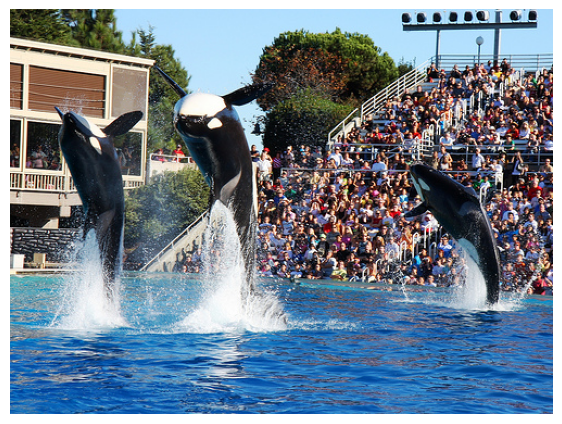

Predicted Caption: man is jumping in the water

Actual Human Captions:
- killer whales perform for crowd
- three dolphins are jumping out of pool in front of crowd of people
- three orca whales jump in pool at seaworld
- three whales are jumping into the air at the same time in front of very large crowd
- three whales are jumping in the air while people watch




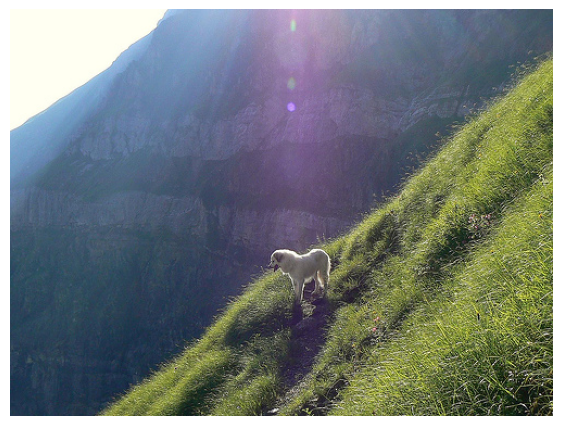

Predicted Caption: man is standing on the edge of the water

Actual Human Captions:
- dog on green hillside
- dog standing on the side of mountain
- dog stands on the side of grassy cliff
- fluffy white dog looks down steep grassy embankment
- white dog is standing on grassy hillside




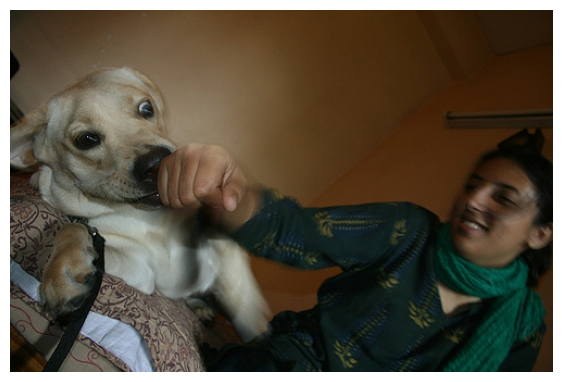

Predicted Caption: two dogs are playing with the camera

Actual Human Captions:
- smiling woman punching dog
- tan dog licks girls hand while laying down
- woman dressed in green is playing with her tan dog
- the girl with the green scarf and the white dog appear to be playing
- the light brown dog with white spots is nibbling on the girls hand




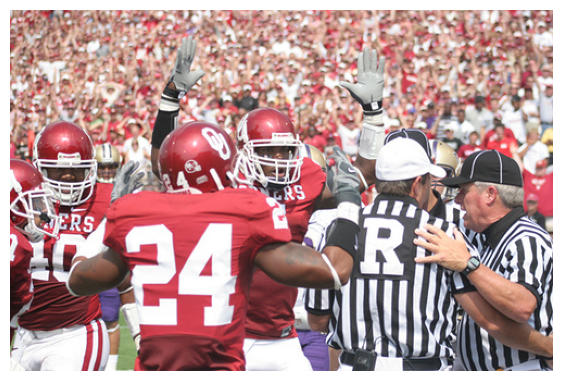

Predicted Caption: football player in red uniform is being the football

Actual Human Captions:
- football player in red and white is holding both hands up
- football players gather around the referees
- football players gathering to contest something to collaborating officials
- oklahoma university football players in front of crowd of sooners fans and next to three referees
- the red and white football team is talking with the officials




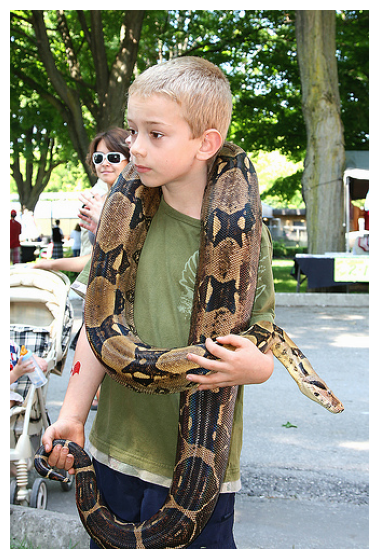

Predicted Caption: man in black shirt and hat and hat and hat and hat

Actual Human Captions:
- blonde boy stands among people in shady setting with large snake wrapped around his chest
- boy carries huge snake around his neck outside
- boy has large snake wrapped around him
- little boy in green shirt is holding large snake
- young boy has snake draped over his shoulders




In [39]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

def visualize_test_predictions(model, descriptions, features, tokenizer, max_length, test_ids, images_dir='data/raw/Images', num_samples=3):
    if not test_ids:
        print("No test IDs available.")
        return
        
    # Pick random samples
    sample_ids = random.sample(test_ids, min(num_samples, len(test_ids)))
    
    for image_id in sample_ids:
        # Load and plot image
        img_path = os.path.join(images_dir, image_id + '.jpg')
        if not os.path.exists(img_path):
            print(f"Image not found: {img_path}")
            continue
            
        img = mpimg.imread(img_path)
        plt.figure(figsize=(7, 7))
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        
        # Generate description
        feature = features[image_id]
        yhat = generate_desc(model, tokenizer, feature, max_length)
        yhat_clean = yhat.replace('startseq ', '').replace(' endseq', '')
        
        # Print results nicely
        print(f"\033[1mPredicted Caption:\033[0m \033[94m{yhat_clean}\033[0m\n")
        print(f"\033[1mActual Human Captions:\033[0m")
        if image_id in descriptions:
            for desc in descriptions[image_id]:
                clean_desc = desc.replace('startseq ', '').replace(' endseq', '')
                print(f"- {clean_desc}")
        print("\n" + "="*60 + "\n")

# Uncomment after training to see visual results:
visualize_test_predictions(eval_model, all_descriptions, all_features, tokenizer, max_length, test_ids, num_samples=5)


### 8.3 Advanced Evaluation Visualizations
Let's add some more visual insights to our evaluation!
1. **BLEU Score Bar Chart**: A visual comparison of BLEU-1 to BLEU-4.
2. **Caption Length Distribution**: Compares if the model is generating shorter or longer captions compared to humans.
3. **Word Cloud**: Shows the most frequently predicted words by the model (helps identify if the model is biased toward certain words like "dog" or "man").

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.translate.bleu_score import corpus_bleu
from tqdm.notebook import tqdm

def visualize_advanced_metrics(model, descriptions, features, tokenizer, max_length, test_ids, sample_size=200):
    if not test_ids:
        print("No test IDs available.")
        return
        
    print(f"Generating captions for {sample_size} test images to build visualizations...")
    sample_ids = test_ids[:sample_size]
    
    actual, predicted = list(), list()
    for key in tqdm(sample_ids, desc="Processing"):
        if key not in features or key not in descriptions:
            continue
        yhat = generate_desc(model, tokenizer, features[key], max_length)
        yhat_clean = yhat.replace('startseq ', '').replace(' endseq', '')
        
        references = [d.replace('startseq ', '').replace(' endseq', '').split() for d in descriptions[key]]
        actual.append(references)
        predicted.append(yhat_clean.split())
        
    # Calculate BLEU scores
    b1 = corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0))
    b2 = corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0))
    b3 = corpus_bleu(actual, predicted, weights=(0.33, 0.33, 0.33, 0))
    b4 = corpus_bleu(actual, predicted, weights=(0.25, 0.25, 0.25, 0.25))
    
    sns.set_theme(style="whitegrid")
    
    # 1. BLEU Score Bar Chart
    plt.figure(figsize=(8, 5))
    sns.barplot(x=['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4'], y=[b1, b2, b3, b4], palette='viridis', hue=['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4'], legend=False)
    plt.title(f'BLEU Scores (Sample of {sample_size} images)')
    plt.ylim(0, 1)
    plt.ylabel('Score')
    plt.show()

    # 2. Sentence Length Distribution (Actual vs Predicted)
    actual_lengths = [len(ref[0]) for ref in actual] # taking the length of the first reference caption
    predicted_lengths = [len(pred) for pred in predicted]
    
    plt.figure(figsize=(10, 5))
    sns.histplot(actual_lengths, color='blue', label='Actual Human Captions', kde=True, stat="density", bins=15, alpha=0.5)
    sns.histplot(predicted_lengths, color='orange', label='Model Predicted Captions', kde=True, stat="density", bins=15, alpha=0.5)
    plt.title('Distribution of Caption Lengths (Actual vs Predicted)')
    plt.xlabel('Number of Words')
    plt.legend()
    plt.show()

    # 3. Word Cloud for Predicted Captions
    predicted_text = " ".join([" ".join(pred) for pred in predicted])
    if not predicted_text.strip():
        print("No words generated for word cloud.")
    else:
        wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Set2').generate(predicted_text)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title('Word Cloud of Predicted Words')
        plt.show()


if EVALUATE_MODEL:
    visualize_advanced_metrics(eval_model, all_descriptions, all_features, tokenizer, max_length, test_ids, sample_size=200)
else:
    print("Generated captions for 200 test images to build visualizations...")


Generated captions for 200 test images to build visualizations...


---
## 9. Single Image Captioning (Task 7)
Now comes the fun part! Let's test the model on completely new images (e.g., from the internet or your phone). 
We need a function that takes a new image path, extracts its VGG16 features, and passes it to our trained model to generate a caption.

In [42]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pickle

# Load VGG16 ONCE and reuse it for every image (avoids reloading ~500MB weights per call)
_vgg_feature_model = None
_inference_model = None

def get_vgg_model():
    global _vgg_feature_model
    if _vgg_feature_model is None:
        print("Loading VGG16 feature extractor (one-time setup)...")
        base_model = VGG16()
        # Re-structure the model exactly as we did in Task 3
        _vgg_feature_model = Model(inputs=base_model.inputs, outputs=base_model.layers[-2].output)
    return _vgg_feature_model

def extract_single_feature(filename):
    vgg_model = get_vgg_model()

    # Load and preprocess image
    image = load_img(filename, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)

    # Get features
    feature = vgg_model.predict(image, verbose=0)
    return feature

def caption_new_image(image_path, model=None, tokenizer=None, max_length=34, beam_search=False, beam_index=3):
    print(f"Processing image: {image_path}")

    # 1. Extract visual features (reuses the cached VGG16 model)
    feature = extract_single_feature(image_path)

    # 2. Generate Caption
    # If model is not passed (e.g. running this in a new session), load the checkpoint ONCE and cache it
    global _inference_model
    if model is None:
        if _inference_model is None:
            print("Loading checkpoint: models/best_model.h5")
            _inference_model = load_model('models/best_model.h5')
        model = _inference_model
    if tokenizer is None:
        with open('models/tokenizer.pkl', 'rb') as f:
            tokenizer = pickle.load(f)

    if beam_search:
        caption = generate_desc_beam_search(model, tokenizer, feature, max_length, beam_index)
    else:
        caption = generate_desc(model, tokenizer, feature, max_length)
    caption_clean = caption.replace('startseq ', '').replace(' endseq', '')

    # 3. Display Image and Caption
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')

    # Add caption as title
    plt.title(caption_clean.capitalize(), fontsize=16, color='darkblue', fontweight='bold')
    plt.show()

    return caption_clean

# Load Models & Predict

In [43]:
#load models

Found 3 example images in data/example/

data/example\image1.jpg
Processing image: data/example\image1.jpg
Loading VGG16 feature extractor (one-time setup)...


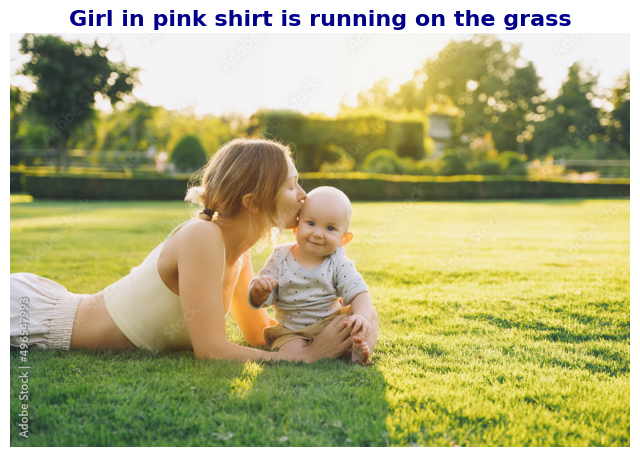

Processing image: data/example\image1.jpg


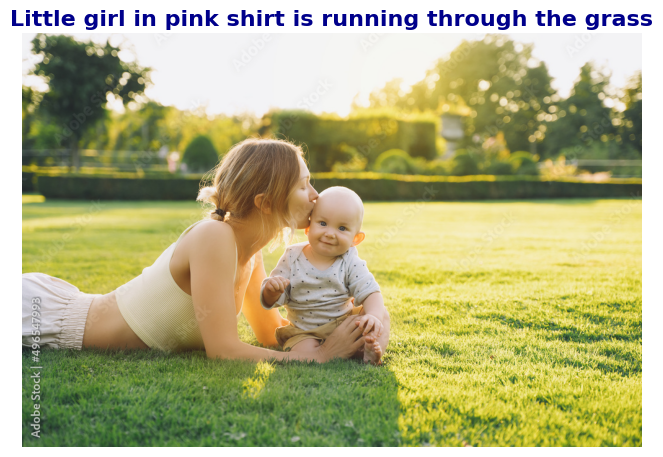


data/example\image2.jpg
Processing image: data/example\image2.jpg


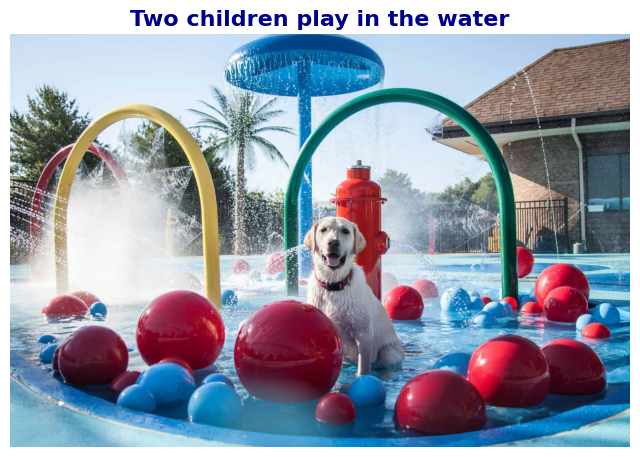

Processing image: data/example\image2.jpg


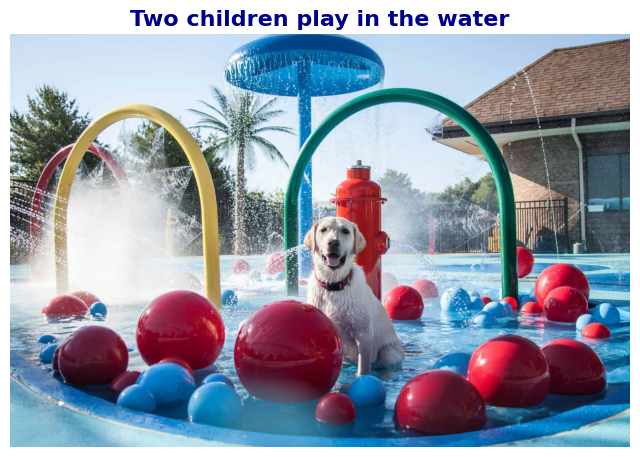


data/example\image3.jpg
Processing image: data/example\image3.jpg


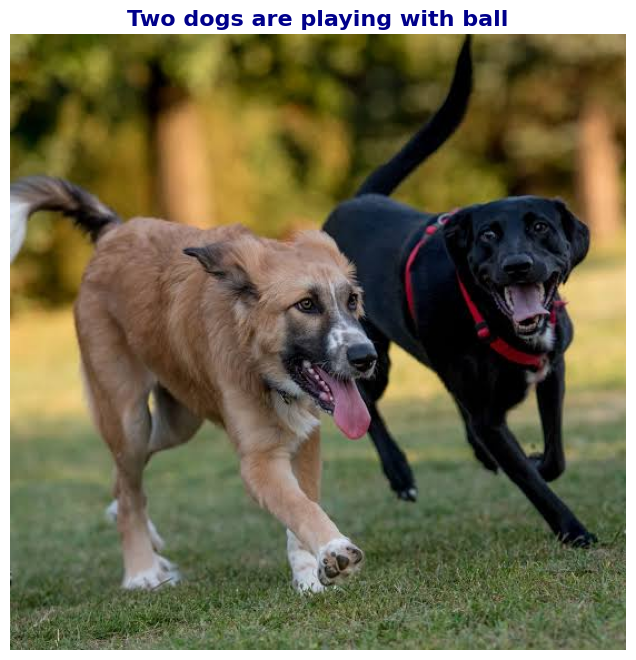

Processing image: data/example\image3.jpg


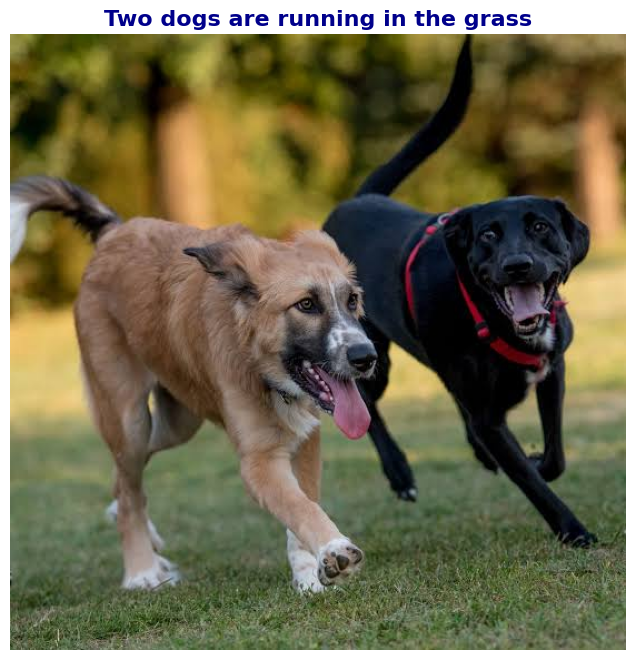

In [44]:
import glob

# Caption every example image in data/example/ with both decoding strategies
example_images = sorted(glob.glob('data/example/*.jpg'))
print(f"Found {len(example_images)} example images in data/example/")

for my_image in example_images:
    print(f"\n{'='*60}\n{my_image}\n{'='*60}")
    caption_new_image(my_image, model=eval_model, tokenizer=tokenizer, max_length=max_length)
    caption_new_image(my_image, model=eval_model, tokenizer=tokenizer, max_length=max_length, beam_search=True, beam_index=3)